# MLP 학습

`customer_features.csv`를 사용해 고빈도 고객 재구매 지연 위험을 예측합니다.

In [1]:
%matplotlib inline

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

FEATURE_PATH = 'data/customer_features.csv'
META_PATH = 'outputs/lstm_sequence_metadata.csv'
OUTPUT_DIR = 'outputs'
MODEL_PATH = 'outputs/mlp_model.pkl'
METRIC_PATH = 'outputs/mlp_metrics.csv'
RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2

print(sys.executable)

/Users/jsh/Desktop/class/3-1/딥러닝응용/고빈도 고객 재구매 지연 위험 예측/venv/bin/python


In [2]:
def resolve_path(path_text: str) -> Path:
    # 경로 확인
    candidates = [Path(path_text), Path(Path(path_text).name)]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'파일을 찾을 수 없습니다: {path_text}')


def load_data():
    # 데이터 불러오기
    feature_file = resolve_path(FEATURE_PATH)
    meta_file = resolve_path(META_PATH)
    features = pd.read_csv(feature_file)
    metadata = pd.read_csv(meta_file)
    print(f'[INFO] feature 크기: {features.shape}')
    print(f'[INFO] metadata 크기: {metadata.shape}')
    return features, metadata


def prepare_data(features: pd.DataFrame, metadata: pd.DataFrame):
    # 데이터 결합
    need_feature = ['user_id', 'total_orders', 'avg_days_between_orders', 'max_order_number']
    need_meta = ['sample_id', 'user_id', 'target_label']
    missing_feature = [c for c in need_feature if c not in features.columns]
    missing_meta = [c for c in need_meta if c not in metadata.columns]
    if missing_feature:
        raise ValueError(f'feature 컬럼이 없습니다: {missing_feature}')
    if missing_meta:
        raise ValueError(f'metadata 컬럼이 없습니다: {missing_meta}')

    df = metadata[need_meta].merge(features[need_feature], on='user_id', how='left')
    feature_cols = ['total_orders', 'avg_days_between_orders', 'max_order_number']
    for col in feature_cols:
        df[col] = df[col].fillna(df[col].median())

    x = df[feature_cols].to_numpy(dtype=np.float32)
    y = df['target_label'].to_numpy(dtype=np.int32)
    sample_id = df['sample_id'].to_numpy(dtype=np.int32)
    print(f'[INFO] 샘플 수: {len(y)}')
    print(f'[INFO] 라벨 분포: {np.bincount(y)}')
    return x, y, sample_id, feature_cols


def split_data(x: np.ndarray, y: np.ndarray, sample_id: np.ndarray):
    # 데이터 분할
    train_idx, test_idx, y_train, y_test = train_test_split(
        sample_id, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
    )
    val_ratio = VAL_SIZE / (1.0 - TEST_SIZE)
    train_idx, _val_idx, _y_train, _y_val = train_test_split(
        train_idx, y_train, test_size=val_ratio, stratify=y_train, random_state=RANDOM_SEED
    )

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x[train_idx])
    x_test = scaler.transform(x[test_idx])
    return x_train, x_test, y[train_idx], y[test_idx], scaler


def train_model(x_train: np.ndarray, y_train: np.ndarray):
    # 모델 학습
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        batch_size=256,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=8,
        random_state=RANDOM_SEED,
        verbose=True,
    )
    model.fit(x_train, y_train)
    return model


def evaluate_model(model, x_test: np.ndarray, y_test: np.ndarray):
    # 성능 평가
    prob = model.predict_proba(x_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, prob),
        'confusion_matrix': confusion_matrix(y_test, pred),
    }


def save_artifacts(model, scaler, feature_cols):
    # 모델 저장
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump({'model': model, 'scaler': scaler, 'feature_cols': feature_cols}, f)
    print(f'[INFO] 저장: {MODEL_PATH}')

[INFO] feature 크기: (42499, 5)
[INFO] metadata 크기: (43890, 4)
[INFO] 샘플 수: 43890
[INFO] 라벨 분포: [42464  1426]
Iteration 1, loss = 0.25291527
Validation score: 0.967534
Iteration 2, loss = 0.14199290
Validation score: 0.967534


Iteration 3, loss = 0.13931000
Validation score: 0.967534
Iteration 4, loss = 0.13846381
Validation score: 0.967534


Iteration 5, loss = 0.13802405
Validation score: 0.967534
Iteration 6, loss = 0.13793259
Validation score: 0.967534
Iteration 7, loss = 0.13777759
Validation score: 0.967534
Iteration 8, loss = 0.13753649
Validation score: 0.967534
Iteration 9, loss = 0.13764284
Validation score: 0.967534


Iteration 10, loss = 0.13755940
Validation score: 0.967534
Validation score did not improve more than tol=0.000100 for 8 consecutive epochs. Stopping.
[INFO] 저장: outputs/mlp_model.pkl


,accuracy,precision,recall,f1,roc_auc
0,0.967532,0.0,0.0,0.0,0.541606


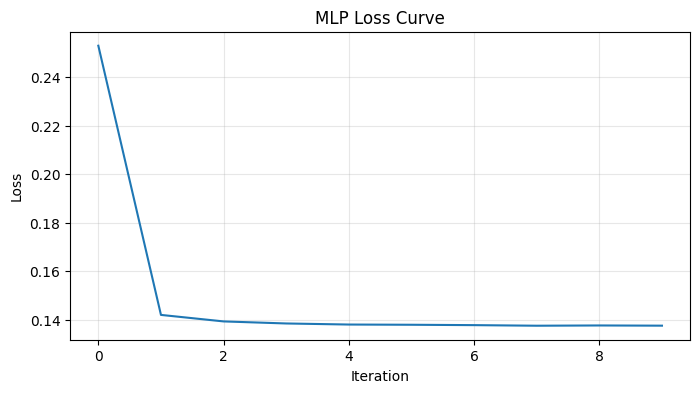

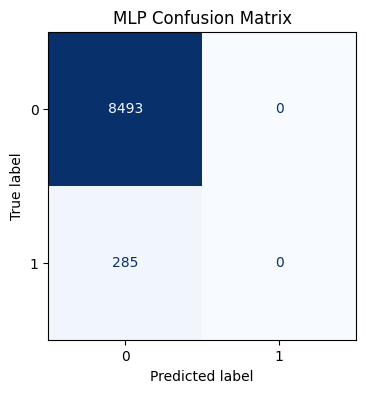

In [3]:
# 실행
features, metadata = load_data()
x, y, sample_id, feature_cols = prepare_data(features, metadata)
x_train, x_test, y_train, y_test, scaler = split_data(x, y, sample_id)
model = train_model(x_train, y_train)
metrics = evaluate_model(model, x_test, y_test)
save_artifacts(model, scaler, feature_cols)

metric_df = pd.DataFrame([{k: v for k, v in metrics.items() if k != 'confusion_matrix'}])
metric_df.to_csv(METRIC_PATH, index=False)
display(metric_df)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_)
plt.title('MLP Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(metrics['confusion_matrix']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('MLP Confusion Matrix')
plt.show()